In [1]:
%matplotlib widget
import numpy as np
import json
import os, math
import pandas as pd
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 14})
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
from IPython.display import clear_output, display

from alvra_tools.load_data import *
from alvra_tools.load_meta import *
from alvra_tools.channels import *
#from alvra_tools.channels_raw import *
from alvra_tools.utils import *
import glob
from alvra_tools.YAG_scans import *
from ipyfilechooser import FileChooser

from Johann_stuff import *

import warnings
warnings.filterwarnings('ignore')

In [2]:
pgroup='p22994'
runnumber = 71
print ('run: {:04d}'.format(runnumber))

#############################################################
jsonfile = ''
jsonfile = glob.glob('/sf/alvra/data/{}/raw/*{:04d}*/meta/scan.json'.format(pgroup, runnumber))[0]
#jsonfile = glob.glob('/sf/alvra/data/p22994/work/Reduced_data/scan.json'.format(pgroup, runnumber))[0]
titlestring = str( pgroup + ' --- ' +jsonfile.split('/')[-3])
print (jsonfile)
from sfdata import SFScanInfo
scan = SFScanInfo(jsonfile)
print ('Scan contains {} step(s), scanvar goes {} to {}'.format(len(scan), scan.readbacks[0], scan.readbacks[-1]))

run: 0071
/sf/alvra/data/p22994/raw/run0071-FePhen_25mM_delayscan_cont_Johann6405eV/meta/scan.json
Scan contains 25 step(s), scanvar goes 0 to 0


# Johann delay scan or fix delay

In [3]:
det = 'JF10T01V01'
threshold_low = 2.5
threshold_high = 100000

detector_Izero = channel_Izero122
motor_delay = channel_delay_beckhoff

channels_list = [detector_Izero, motor_delay]

numsteps = None
I0_threshold = 0.5
quantile = 0.7
########################################################################################
import sfdata.sfdatafile
sfdata.sfdatafile.ju = None
scan = SFScanInfo(jsonfile)

(intensity_on, intensity_off, intensity_on_shots, intensity_off_shots, Delays_fs_shot, ROIs, readbacks, meta) = \
Johann_scan(det, scan, channels_list, threshold_low, threshold_high, I0_threshold=I0_threshold, quantile=quantile, numsteps=numsteps)

length = len(scan)
if numsteps !=None:
    length = numsteps
ints_on, ints_off = unwrap_data_PP(ROIs, length, intensity_on, intensity_off)
ints_on_shot, ints_off_shot = unwrap_data_PP_delayscan(ROIs, length, intensity_on_shots, intensity_off_shots)
print (ROIs)
print (len(ints_on_shot['JF10T01V01:ROI_Ka']), len(ints_on_shot['JF10T01V01:ROI_Ka']), len(Delays_fs_shot))

Took 5.84 seconds for the previous step
Processing: run0071-FePhen_25mM_delayscan_cont_Johann6405eV
Step 25 of 25: Processing acq0025

--------------------------------------------------------------------------------

JF10T01V01:ROI_Ka                5001 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
JF10T01V01:ROI_Ka_thin           5001 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAR-CVME-TIFALL4:EvtSet          5001 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-PBPS122:INTENSITY        4983 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SLAAR11-L-BECKBS:PR1_CH4_VAL_GET 5001 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇

over the whole data set: 4981 / 5003 -> 0% loss
complete channels: 0 / 5 -> 100% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
Laser rep rate is 50.0 Hz (delayed or dark)
Pump scheme is 1:1
Loaded 2440 pump and 2440 unpump shots
['JF10T01V01:ROI_Ka', 'JF10T01V01:ROI_Ka_thin']
29669 29669 29781


# Johann static (no pump)

In [253]:
det = 'JF10T01V01'
threshold_low = 2.5
threshold_high = 100000

detector_Izero = channel_Izero122
channels_list = [detector_Izero]

numsteps = None

########################################################################################
import sfdata.sfdatafile
sfdata.sfdatafile.ju = None
scan = SFScanInfo(jsonfile)

intensity, intensity_shots, ROIs, readbacks, meta = \
Johann_static(det, scan, channels_list, threshold_low, threshold_high, numsteps=numsteps)

length = len(scan)
if numsteps !=None:
    length = numsteps
ints = unwrap_data_static(ROIs, length, intensity)
print (ROIs)
print (np.shape(ints['JF10T01V01:ROI_Ka']))

Took 0.33 seconds for the previous step
Processing: run0064-FeFoil_Ka
Step 241 of 241: Processing acq0241

--------------------------------------------------------------------------------

JF10T01V01:ROI_Ka         101 / 101 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
JF10T01V01:ROI_Ka_thin    101 / 101 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAR-CVME-TIFALL4:EvtSet   101 / 101 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-PBPS122:INTENSITY  99 / 101 -> 2% loss ▇▇▇▇▇▇▇▇▇

over the whole data set: 99 / 101 -> 2% loss
complete channels: 3 / 4 -> 25% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
['JF10T01V01:ROI_Ka', 'JF10T01V01:ROI_Ka_thin']
(241,)


# von Hamos static (no pump)

In [3]:
det = 'JF09T01V01'
threshold_low = 2.5
threshold_high = 100000

detector_Izero = channel_Izero122

channels_list = [detector_Izero]

numsteps = None   # how many acquisitions are read (should be 13 for run 075 to compare with Johann)

#badruns = [87, 88, 89, 90, 108]
badruns = []
threshold_FEL = 0

reducedir = '/sf/alvra/data/p22994/work/Reduced_data/'
########################################################################################
runname = jsonfile.split('/')[-3]
savedir = reducedir+runname
os.makedirs(savedir, mode=0o775, exist_ok=True)

import sfdata.sfdatafile
sfdata.sfdatafile.ju = None
scan = SFScanInfo(jsonfile)

(spectra, spectra_shots, ROIs, readbacks, meta) = \
VonHamos_static(det, scan, channels_list, threshold_low, threshold_high, savedir, threshold_FEL, badruns, numsteps=numsteps)

length = len(scan)-len(badruns)
if numsteps !=None:
    length = numsteps
specs = unwrap_data_static(ROIs, length, spectra)

print (ROIs)
print (np.shape(specs['JF09T01V01:ROI_Ka']))

Took 0.78 seconds for the previous step
Processing: run0017-FLEX_vonHamos_Fe25um
Step 5 of 5: Processing acq0005

--------------------------------------------------------------------------------

JF09T01V01:ROI_Ka         1001 / 1001 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
JF09T01V01:ROI_Ka_VHS     1001 / 1001 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
JF09T01V01:ROI_Ka_narrow  1001 / 1001 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
JF09T01V01:ROI_Ka_thin    1001 / 1001 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAR-CVME-TIFALL4:EvtSet   1001 / 1001 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-PBPS122:INTENSITY 1001 / 1001 -> 0% loss ▇▇▇▇▇▇▇▇▇▇

over the whole data set: 1001 / 1001 -> 0% loss
complete channels: 6 / 6 -> 0% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
['JF09T01V01:ROI_Ka', 'JF09T01V01:ROI_Ka_VHS', 'JF09T01V01:ROI_Ka_narrow', 'JF09T01V01:ROI_Ka_thin']
(5, 25)


In [6]:
np.shape(spectra[0]['JF09T01V01:ROI_Ka'])

(25,)

# von Hamos delay scan or fix delay

In [273]:
det = 'JF10T01V01'
threshold_low = 2.5
threshold_high = 100000

detector_Izero = channel_Izero122
motor_delay = channel_delay_beckhoff

channels_list = [detector_Izero, motor_delay]

numsteps = 25   # how many acquisitions are read (should be 25 for run 075 to compare with Johann)

#badruns = [87, 88, 89, 90, 108]
badruns = []
threshold_FEL = 0

reducedir = '/sf/alvra/data/p22994/work/Reduced_data/'
########################################################################################
runname = jsonfile.split('/')[-3]
savedir = reducedir+runname
os.makedirs(savedir, mode=0o775, exist_ok=True)

import sfdata.sfdatafile
sfdata.sfdatafile.ju = None
scan = SFScanInfo(jsonfile)

(spectra_on, spectra_off, spectra_on_shots, spectra_off_shots, Delays_fs_shot, ROIs, readbacks, meta) = \
VonHamos_scan(det, scan, channels_list, threshold_low, threshold_high, savedir, threshold_FEL, badruns, numsteps=numsteps)

length = len(scan)-len(badruns)
if numsteps !=None:
    length = numsteps
specs_on, specs_off = unwrap_data_PP(ROIs, length, spectra_on, spectra_off)
specs_on_shot, specs_off_shot = unwrap_data_PP_delayscan(ROIs, length, spectra_on_shots, spectra_off_shots)
print (ROIs)
print (np.shape(specs_on['JF10T01V01:ROI_Ka']), np.shape(specs_off['JF10T01V01:ROI_Ka']))
print (np.shape(specs_on_shot['JF10T01V01:ROI_Ka']), np.shape(specs_off_shot['JF10T01V01:ROI_Ka']), len(Delays_fs_shot))

Took 20.85 seconds for the previous step
Processing: run0075-FePhen_25mM_delayscan_cont_VHS
Step 25 of 25: Processing acq0025

--------------------------------------------------------------------------------

JF10T01V01:ROI_Ka                5001 / 5004 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
JF10T01V01:ROI_Ka_thin           5001 / 5004 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAR-CVME-TIFALL4:EvtSet          5001 / 5004 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-PBPS122:INTENSITY        4983 / 5004 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SLAAR11-L-BECKBS:PR1_CH4_VAL_GET 5001 / 5004 -> 0% loss ▇▇▇▇▇▇▇▇▇▇

over the whole data set: 4980 / 5004 -> 0% loss
complete channels: 0 / 5 -> 100% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
Laser rep rate is 50.0 Hz (delayed or dark)
Pump scheme is 1:1
Loaded 2436 pump and 2436 unpump shots
['JF10T01V01:ROI_Ka', 'JF10T01V01:ROI_Ka_thin']
(25, 1100) (25, 1100)
(60809, 1100) (60809, 1100) 60809


## Plot for delay scan with Johann

In [4]:
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
runname

'run0071-FePhen_25mM_delayscan_cont_Johann6405eV'

In [5]:
### ---- from run0072 ---- ####
#offset   = 22143245.819978923
#areanorm = 886702650.1128838 * 800/5000

offset   = 9098.168660881982
areanorm = 181577.7786205812   #363155.5572411624

In [6]:
minvalue = -500 
maxvalue = 1000
binsize = 20

temp_on  = np.array(ints_on_shot['JF10T01V01:ROI_Ka'])
temp_off = np.array(ints_off_shot['JF10T01V01:ROI_Ka'])

temp_on = temp_on - offset
temp_off = temp_off - offset

ints_on  = temp_on/areanorm
ints_off = temp_off/areanorm

#######################################################################################

binList = np.arange(minvalue, maxvalue, binsize)
bin_centres = (binList[:-1] + binList[1:])/2
delay_rebin = np.arange(minvalue + binsize/2, maxvalue - binsize/2, binsize)
ONs  = np.zeros(len(bin_centres))
OFFs = np.zeros(len(bin_centres))
PPs  = np.zeros(len(bin_centres))
err_PP = np.zeros(len(bin_centres))

howmany = []

for i in range(len(bin_centres)):
    cond1 = Delays_fs_shot >= binList[i]
    cond2 = Delays_fs_shot < binList[i+1]
    idx = np.where(cond1*cond2)[0]
    howmany.append(len(idx))

    pump   = np.array(ints_on)[idx]
    unpump = np.array(ints_off)[idx]
    pumpprobe = pump - unpump
    
    ONs[i]  = np.sum(pump)
    OFFs[i] = np.sum(unpump)
    PPs[i]  = np.nanmean(pumpprobe)
    err_PP[i] = np.nanstd(pumpprobe)/np.sqrt(len(pumpprobe))

# fig = plt.figure(figsize = (7,5))
# fig.suptitle(titlestring)
# ax1 = fig.add_subplot(111)
# ax2 = plt.twinx(ax1)

# delayrange = np.arange(0, len(delay_rebin), 1)
# ax1.plot(delay_rebin, np.array(howmany), color = 'darkorange')
# ax2.scatter(delay_rebin, delayrange, s = 5)

# ax1.set_ylabel('shots per bin', color='darkorange')
# ax1.set_xlabel('Delay (fs)')
# ax1.grid()
# plt.show()



fit = Fit(errfunc_fwhm, estimate_errfunc_parameters)
fit.estimate(delay_rebin, PPs)
fit.p0 = better_p0(fit.p0, 0, 0) 

fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [2, 1]}, figsize=(7,7))
ax1.axes.xaxis.set_ticklabels([])

fit.fit(delay_rebin,PPs, maxfev=200000)     
pp_fit = fit.eval(delay_rebin)
t0_fs = fit.popt[0]
width_fs = fit.popt[2]

#plt.title(titlestring)
ax1.plot(delay_rebin+100, pp_fit, color='green', label='Fit to the data')
ax1.errorbar(delay_rebin+100, PPs, err_PP, fmt='o', lw=1,color='red', markersize=3,capsize=1,capthick=1, ecolor='red',elinewidth=1,
            label='{} total shots'.format(len(Delays_fs_shot)))

# ax1.plot(delay_rebin+100, OFFs)
# ax1.plot(delay_rebin+100, ONs)

ax2.scatter(delay_rebin+100, np.array(howmany), s=10, color = 'darkorange')

ax1.set_ylabel('Intensity difference')
ax1.set_xlim(-400, 530)

ax2.set_ylabel('shots per bin', labelpad=20)
ax2.set_ylim(0, 1000)
ax2.set_xlim(-400, 530)


ax1.grid()
ax1.legend(loc='best')
ax2.set_xlabel('Delay (fs)')
ax2.grid()
plt.tight_layout()
plt.show()


#plt.savefig(savedir + '/' + '{}.png'.format(runname))
print("Width = {:.4f} fs".format(abs(width_fs)))

IndexError: index 29780 is out of bounds for axis 0 with size 29669

In [47]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
df = pd.DataFrame({
    "delay": [delay_rebin], 
    "intensity_on": [ONs],
    "intensity_off": [OFFs],
    "pump_probe": [PPs], 
    "errors_pp": [err_PP],
    "intensity_on_shots": [ints_on],
    "intensity_off_shots": [ints_off],
    "howmany": [howmany]
})

csv_file = os.path.join(savedir, '{}.csv'.format(runname))
df.to_csv(csv_file, index=False)

## Plot for Johann scan at fixed delay

In [188]:
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
runname

'run0072-FePhen_25mM_XES_1ps'

9098.168660881982
181577.7786205812


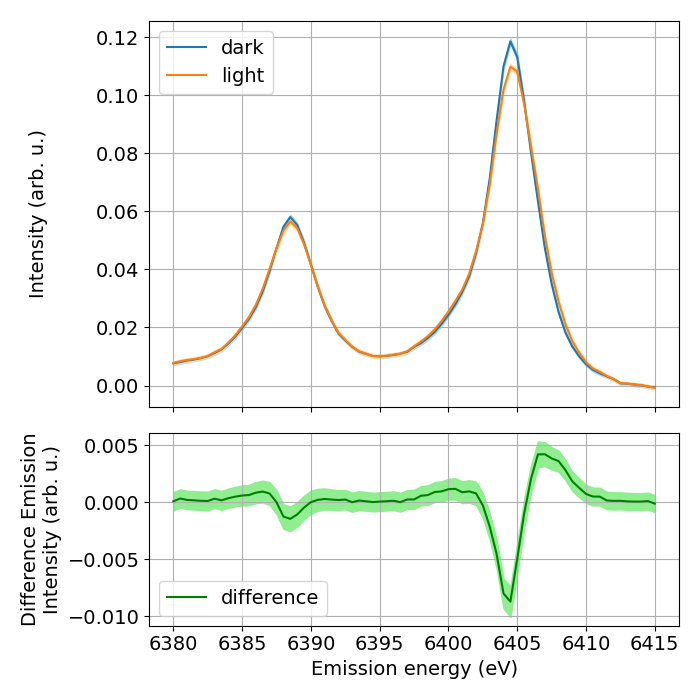

In [201]:
intensity_Ka_on  = np.array(ints_on['JF10T01V01:ROI_Ka'])
intensity_Ka_off = np.array(ints_off['JF10T01V01:ROI_Ka'])
errors_Ka_on     = np.sqrt(intensity_Ka_on)
errors_Ka_off    = np.sqrt(intensity_Ka_off)
low_err  = intensity_Ka_on - intensity_Ka_off - np.sqrt(errors_Ka_on**2+errors_Ka_off**2)
high_err = intensity_Ka_on - intensity_Ka_off + np.sqrt(errors_Ka_on**2+errors_Ka_off**2)

print (np.mean(intensity_Ka_off[-5:]))

intensity_Ka_on  = intensity_Ka_on - np.mean(intensity_Ka_off[-5:])
intensity_Ka_off = intensity_Ka_off - np.mean(intensity_Ka_off[-5:])

delta = readbacks[1]-readbacks[0]
areanorm = np.sum(intensity_Ka_off)*delta
print (areanorm)

low_err          = low_err/areanorm
high_err         = high_err/areanorm
errors_Ka_on     = errors_Ka_on/areanorm
errors_Ka_off    = errors_Ka_off/areanorm
intensity_Ka_on  = intensity_Ka_on/areanorm
intensity_Ka_off = intensity_Ka_off/areanorm

fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [2, 1]}, figsize=(7,7))
ax1.axes.xaxis.set_ticklabels([])
#ax1.plot(x, y)
#ax2.plot(x, -y)

#fig = plt.figure(figsize=(9,6))
#fig.suptitle(titlestring)
#ax1 = fig.add_subplot(111)
#ax2 = plt.twinx(ax1)

# ax1.errorbar(readbacks[:length], intensity_Ka_on, errors_Ka_on, lw=1, markersize=0,capsize=1,capthick=1, elinewidth=1,label='on')
# ax1.errorbar(readbacks[:length], intensity_Ka_off, errors_Ka_off, lw=1, markersize=0,capsize=1,capthick=1, elinewidth=1,label='off')
# ax2.errorbar(readbacks[:length], intensity_Ka_on-intensity_Ka_off, errors_pp, lw=1, color='green', markersize=0,capsize=1,capthick=1, elinewidth=1,label='pp')

ax1.plot(readbacks[:length], intensity_Ka_off, label='dark')
ax1.fill_between(readbacks[:length], intensity_Ka_off-errors_Ka_off, intensity_Ka_off+errors_Ka_off, color='lightblue')
ax1.plot(readbacks[:length], intensity_Ka_on, label='light')
ax1.fill_between(readbacks[:length], intensity_Ka_on-errors_Ka_on, intensity_Ka_on+errors_Ka_on, color='navajowhite')
ax2.plot(readbacks[:length], intensity_Ka_on-intensity_Ka_off, label='difference', color='green')
ax2.fill_between(readbacks[:length], low_err, high_err, color='lightgreen')
#plt.errorbar(delay_rebin, PPs, err_PP, lw=1,color='red', markersize=0,capsize=1,capthick=1, ecolor='red',elinewidth=1)

ax1.set_ylabel('Intensity (arb. u.)',labelpad=35)
ax2.set_xlabel('Emission energy (eV)')
ax2.set_ylabel('Difference Emission\nIntensity (arb. u.)')
#ax2.set_ylim(-0.005, 0.005)

ax1.legend(loc='upper left')
ax2.legend(loc='lower left')
ax1.grid()
ax2.grid()
plt.tight_layout()
plt.show()

plt.savefig(savedir + '/' + '{}.png'.format(runname))

In [12]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
df = pd.DataFrame({
    "energy": [readbacks], 
    "intensity_on": [intensity_Ka_on],
    "intensity_off": [intensity_Ka_off],
    "errors_Ka_on": [errors_Ka_on],
    "errors_Ka_off": [errors_Ka_off]
})

csv_file = os.path.join(savedir, '{}.csv'.format(runname))
df.to_csv(csv_file, index=False)

## Plot for Johann static (no pump)

In [254]:
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
runname

'run0064-FeFoil_Ka'

In [255]:
ka2 = 6404
ka1 = 6421.05

m = (6404 - 6391)/(ka1 - ka2)
q = (ka1*6391-ka2*6404)/(ka1-ka2)
yaxis_e = m*(readbacks) + q
m

0.7624633431084963

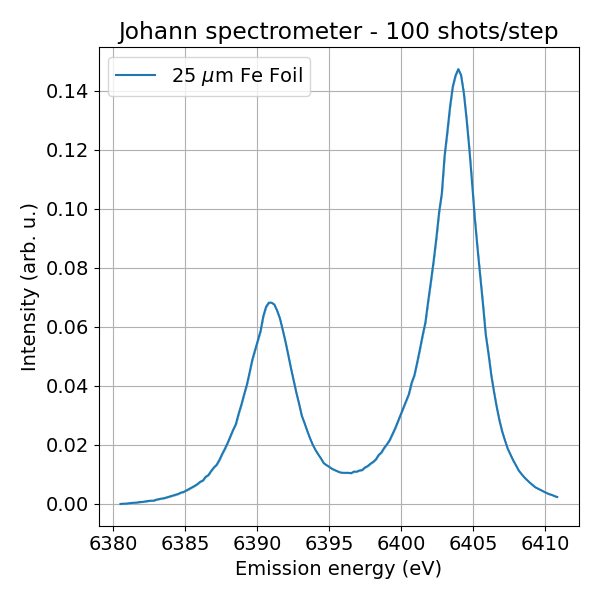

In [257]:
intensity_Ka  = np.array(ints['JF10T01V01:ROI_Ka'])

rbk = yaxis_e[81:]
int_Ka = intensity_Ka[81:]-np.mean(intensity_Ka[81]) #intensity_Ka[81:]
err_int = np.sqrt(int_Ka)

plt.figure(figsize=(6,6))
plt.rcParams.update({'font.size': 14})
plt.title('Johann spectrometer - 100 shots/step')

delta = rbk[1]-rbk[0]
#plt.pcolormesh(roi_Ka)
plt.plot(rbk, int_Ka/(np.sum(int_Ka)*delta), label='25 $\\mu$m Fe Foil')
plt.fill_between(rbk, (int_Ka-err_int)/(np.sum(int_Ka)*delta), (int_Ka+err_int)/(np.sum(int_Ka)*delta), color='lightblue')
#plt.plot(yaxis, np.sum(proj_all, axis=0))
plt.legend(loc='upper left')
plt.ylabel('Intensity (arb. u.)')
plt.xlabel('Emission energy (eV)')
#plt.colorbar()
plt.grid()
plt.tight_layout()
plt.show()

plt.savefig(savedir + '/' + '{}.png'.format(runname))

In [64]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
df = pd.DataFrame({
    "energy": [rbk], 
    "intensity": [int_Ka],
    "err_intensity": [err_int]
})

csv_file = os.path.join(savedir, '{}.csv'.format(runname))
df.to_csv(csv_file, index=False)

## Plot for Von Hamos static (no pump)

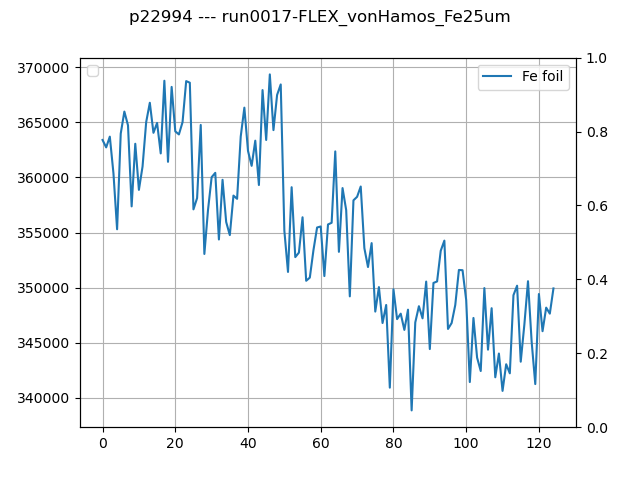

In [4]:
specs_2plot  = np.ravel(specs['JF09T01V01:ROI_Ka'])

fig = plt.figure()
fig.suptitle(titlestring)
ax1 = fig.add_subplot(111)
ax2 = plt.twinx(ax1)

ax1.plot(specs_2plot, label='Fe foil')
#ax1.plot(specs_off_2plot, label='off')
#ax2.plot(np.array(specs_on_2plot)-np.array(specs_off_2plot), label='pp', color='green')

ax1.legend()
ax2.legend(loc='upper left')
ax1.grid()
plt.show()

## Plot for Von Hamos at fix delay

In [274]:
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
runname

'run0075-FePhen_25mM_delayscan_cont_VHS'

In [242]:
ka2 = 481
ka1 = 643

m = (6404 - 6391)/(ka1 - ka2)
q = (ka1*6391-ka2*6404)/(ka1-ka2)
yaxis = np.arange(0, 1100)
yaxis_e = m*(yaxis) + q
1/m

12.461538461538462

39.02353803665498
239.20322225993542


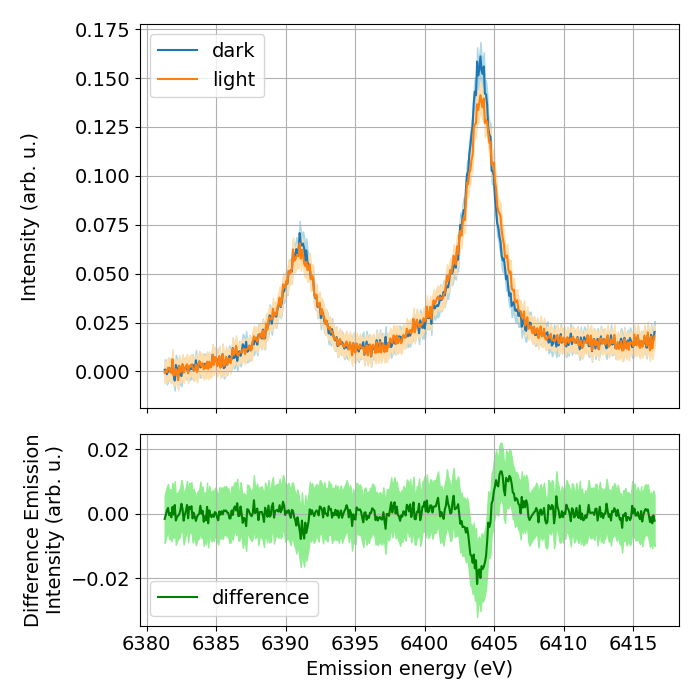

In [244]:
###### ---- [360:800] for run0073 & run0074 ---- ##########3
energy= yaxis_e[360:800]
# intensity_Ka_on   = np.sum(specs_on['JF10T01V01:ROI_Ka'], axis=0)[360:800]
# intensity_Ka_off  = np.sum(specs_off['JF10T01V01:ROI_Ka'], axis=0)[360:800]
intensity_Ka_on   = specs_on['JF10T01V01:ROI_Ka'][0][360:800]
intensity_Ka_off  = specs_off['JF10T01V01:ROI_Ka'][0][360:800]

errors_Ka_on     = np.sqrt(intensity_Ka_on)/np.sqrt(len(specs_off['JF10T01V01:ROI_Ka']))
errors_Ka_off    = np.sqrt(intensity_Ka_off)/np.sqrt(len(specs_off['JF10T01V01:ROI_Ka']))
low_err  = intensity_Ka_on - intensity_Ka_off - np.sqrt(errors_Ka_on**2+errors_Ka_off**2)
high_err = intensity_Ka_on - intensity_Ka_off + np.sqrt(errors_Ka_on**2+errors_Ka_off**2)

print (np.mean(intensity_Ka_off[:10]))

intensity_Ka_on  = intensity_Ka_on - np.mean(intensity_Ka_off[:10])
intensity_Ka_off = intensity_Ka_off - np.mean(intensity_Ka_off[:10])

delta = energy[1]-energy[0]
areanorm = np.sum(intensity_Ka_off)*delta
print (areanorm)

low_err          = low_err/areanorm
high_err         = high_err/areanorm
errors_Ka_on     = errors_Ka_on/areanorm
errors_Ka_off    = errors_Ka_off/areanorm
intensity_Ka_on  = intensity_Ka_on/areanorm
intensity_Ka_off = intensity_Ka_off/areanorm

fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [2, 1]}, figsize=(7,7))
ax1.axes.xaxis.set_ticklabels([])

ax1.plot(energy, intensity_Ka_off, label='dark')
ax1.fill_between(energy, intensity_Ka_off-errors_Ka_off, intensity_Ka_off+errors_Ka_off, color='lightblue')
ax1.plot(energy, intensity_Ka_on, label='light')
ax1.fill_between(energy, intensity_Ka_on-errors_Ka_on, intensity_Ka_on+errors_Ka_on, color='navajowhite')
ax2.plot(energy, intensity_Ka_on-intensity_Ka_off, label='difference', color='green')
ax2.fill_between(energy, low_err, high_err, color='lightgreen')

ax1.set_ylabel('Intensity (arb. u.)',labelpad=25)
ax2.set_xlabel('Emission energy (eV)')
ax2.set_ylabel('Difference Emission\nIntensity (arb. u.)')
#ax2.set_ylim(-0.002, 0.002)

ax1.legend(loc='upper left')
ax2.legend(loc='lower left')
ax1.grid()
ax2.grid()
plt.tight_layout()
plt.show()

plt.savefig(savedir + '/' + '{}.png'.format(runname))

In [34]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
df = pd.DataFrame({
    "energy": [readbacks], 
    "intensity_on": [intensity_Ka_on],
    "intensity_off": [intensity_Ka_off],
    "errors_Ka_on": [errors_Ka_on],
    "errors_Ka_off": [errors_Ka_off]
})

csv_file = os.path.join(savedir, '{}.csv'.format(runname))
df.to_csv(csv_file, index=False)

## Plot for Von Hamos delayscan

In [275]:
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
runname

'run0075-FePhen_25mM_delayscan_cont_VHS'

In [291]:
### ---- from run0073 ---- ####

#offset   = 1142.3297716932104
#areanorm = 74395.27796566964

# offset = 45.95572444201124
# areanorm = 2980.8401543031887 * 13

offset = 969.3174973544437
areanorm = 239.20322225993542 * 13  #2980.8401543031887 #5969.991441715434

In [292]:
minvalue = -400
maxvalue = 1000
binsize = 20

#######################################################################################

binList = np.arange(minvalue, maxvalue, binsize)
bin_centres = (binList[:-1] + binList[1:])/2
delay_rebin = np.arange(minvalue + binsize/2, maxvalue - binsize/2, binsize)

s_rebin_on = {}
s_rebin_off = {}
err_s_rebin_on  = {}
err_s_rebin_off = {}

for j,ROI in enumerate(ROIs):
    ROI_size = np.array(meta[ROI+'-roi'])[1][1]-np.array(meta[ROI+'-roi'])[1][0]
    
    temp_s_on  = np.array(specs_on_shot[ROI])[:,:ROI_size]
    temp_s_off  = np.array(specs_off_shot[ROI])[:,:ROI_size]
    
    spec_rebin_on   = np.zeros((len(bin_centres), ROI_size)) 
    spec_rebin_off  = np.zeros((len(bin_centres), ROI_size))
    err_spec_rebin_on   = np.zeros((len(bin_centres), ROI_size))
    err_spec_rebin_off   = np.zeros((len(bin_centres), ROI_size))
    howmany = []
    
    for i in range(len(bin_centres)):
        cond1 = Delays_fs_shot >= binList[i]
        cond2 = Delays_fs_shot < binList[i+1]

        idx = np.where(cond1*cond2)[0]
        howmany.append(len(idx))

        spec_rebin_on[i]  = np.mean(temp_s_on[idx,:], axis=0)
        spec_rebin_off[i] = np.mean(temp_s_off[idx,:], axis=0)
        err_spec_rebin_on[i] = np.std(temp_s_on[idx,:], axis=0)/np.sqrt(len(idx))
        err_spec_rebin_off[i] = np.std(temp_s_off[idx,:], axis=0)/np.sqrt(len(idx))
        
    s_rebin_on[ROI]      = spec_rebin_on
    s_rebin_off[ROI]     = spec_rebin_off
    err_s_rebin_on[ROI]  = err_spec_rebin_on
    err_s_rebin_off[ROI] = err_spec_rebin_off

# fig = plt.figure(figsize = (7,5))
# fig.suptitle(titlestring)
# ax1 = fig.add_subplot(111)
# ax2 = plt.twinx(ax1)

# delayrange = np.arange(0, len(delay_rebin), 1)
# ax1.plot(delay_rebin, np.array(howmany), color = 'darkorange')
# ax2.scatter(delay_rebin, delayrange, s = 5)

# ax1.set_ylabel('shots per bin', color='darkorange')
# ax1.grid()
# plt.show()

#os.makedirs(savedir, exist_ok=True)
#plt.savefig(savedir + '/' + 'bins_population.png')

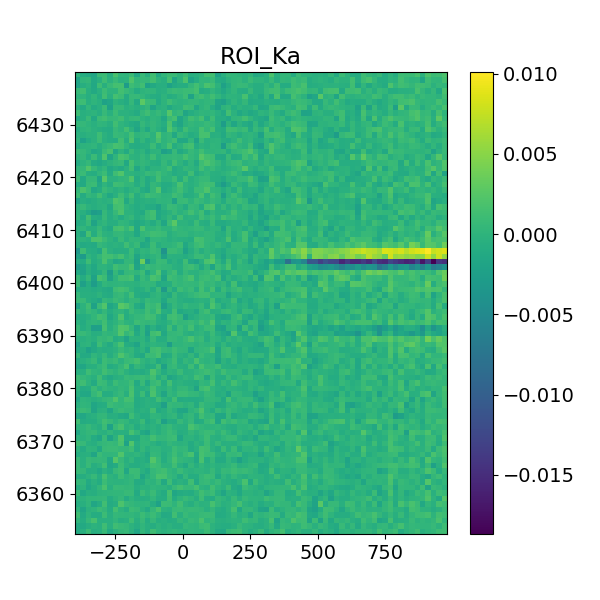

In [293]:
ROI = 'JF10T01V01:ROI_Ka'

bin_ = 13   # rebining energy bins to correspond to ~ 1 eV

vmin = None
vmax = None

##########################################################
ROI_size = np.array(meta[ROI+'-roi'])[1][1]-np.array(meta[ROI+'-roi'])[1][0]
plt.figure(figsize=(6,6))
#areanorm=1
matrix_on = (s_rebin_on[ROI])/areanorm
matrix_off =  (s_rebin_off[ROI])/areanorm
err_matrix_on = (err_s_rebin_on[ROI])/areanorm
err_matrix_off = (err_s_rebin_off[ROI])/areanorm

yaxis = np.arange(np.array(meta[ROI+'-roi']).flatten()[-2], np.array(meta[ROI+'-roi']).flatten()[-1], 1)

# Quick calibration pixel to eV using the Ka1,2 peaks
ka2 = 1981 - 1500
ka1 = 2143 - 1500
m = (6404 - 6391)/(ka1 - ka2)        # pixel-to-eV
q = (ka1*6391-ka2*6404)/(ka1-ka2)
yaxis_e = m*(yaxis-1500) + q

y_axis_rebin, matrix_on_rebin  = plot_tool_static_2D(matrix_on, 0, yaxis_e, bin_)
y_axis_rebin, matrix_off_rebin = plot_tool_static_2D(matrix_off, 0, yaxis_e, bin_)
y_axis_rebin, err_matrix_on_rebin = plot_tool_static_2D(err_matrix_on, 0, yaxis_e, bin_)
y_axis_rebin, err_matrix_off_rebin = plot_tool_static_2D(err_matrix_off, 0, yaxis_e, bin_)

pp = np.transpose(np.asarray(matrix_on_rebin) - np.asarray(matrix_off_rebin))
pp_err = np.transpose(np.sqrt(np.asarray(err_matrix_on_rebin)**2 + np.asarray(err_matrix_off_rebin)**2))

plt.title(ROI.split(':')[-1])
#plt.plot(Delay_fs, (np.transpose(np.asarray(matrix_on_rebin) - np.asarray(matrix_off_rebin))[31]))

#plt.pcolormesh(Delay_fs, y_axis_rebin, np.transpose(np.asarray(matrix_on_rebin) - np.asarray(matrix_off_rebin)), vmin = vmin, vmax = vmax)
plt.pcolormesh(delay_rebin, y_axis_rebin, pp, vmin = vmin, vmax = vmax)
#plt.pcolormesh(delay_rebin, y_axis_rebin, np.transpose(np.asarray(err_matrix_on_rebin)), vmin = vmin, vmax = vmax)
#plt.pcolormesh(Delay_fs, y_axis_rebin, np.transpose(np.asarray(matrix_off_rebin)), vmin = vmin, vmax = vmax)
plt.colorbar()
#plt.ylabel(ylabel)
#plt.axhline(y = 5098, color = 'r', linestyle = '-')
#plt.axvline(x = 2.55, color = 'r', linestyle = '-')

#plt.xlabel('{} ({})'.format(scan.parameters['name'][0], scan.parameters['units'][0]))
plt.show()

In [294]:
energy = 6403.85
index_energy = np.arange(len(y_axis_rebin))[(np.array(y_axis_rebin) > energy)][0]
cut_e = np.array(pp)[index_energy,:]
err_cut = np.array(pp_err)[index_energy,:]
print (index_energy)

49


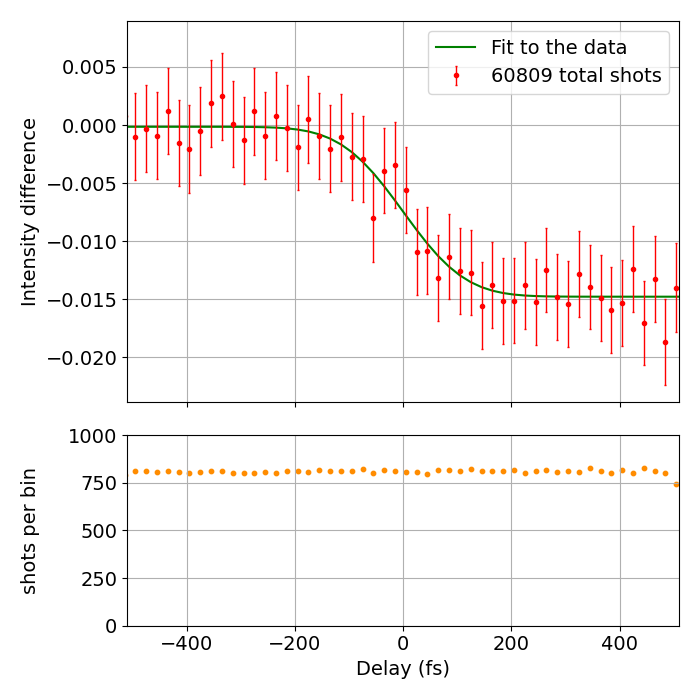

Width = 214.9284 fs


In [298]:

indexNans = ~(np.isnan(delay_rebin) | np.isnan(cut_e))
delay_rebin2 = delay_rebin[indexNans]
cut_e2=  cut_e[indexNans]
err_cut2=  err_cut[indexNans]

fit = Fit(errfunc_fwhm, estimate_errfunc_parameters)
fit.estimate(delay_rebin2, cut_e2)
fit.p0 = better_p0(fit.p0, 0, 0) 

fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [2, 1]}, figsize=(7,7))
ax1.axes.xaxis.set_ticklabels([])

fit.fit(delay_rebin2,cut_e2, maxfev=200000)     
pp_fit = fit.eval(delay_rebin2)
t0_fs = fit.popt[0]
width_fs = fit.popt[2]

#plt.title(titlestring)
ax1.plot(delay_rebin2-445, pp_fit, color='green', label='Fit to the data')
ax1.errorbar(delay_rebin2-445, cut_e2, err_cut2, fmt='o', lw=1,color='red', markersize=3,capsize=1,capthick=1, ecolor='red',elinewidth=1,
            label='{} total shots'.format(len(Delays_fs_shot)))

# ax1.plot(delay_rebin+100, OFFs)
# ax1.plot(delay_rebin+100, ONs)

ax2.scatter(delay_rebin2-445, np.array(howmany), s=10, color = 'darkorange')

ax1.set_ylabel('Intensity difference')
ax1.set_xlim(-510, 510)

ax2.set_ylabel('shots per bin', labelpad=20)
ax2.set_ylim(0, 1000)
ax2.set_xlim(-510, 510)


ax1.grid()
ax1.legend(loc='best')
ax2.set_xlabel('Delay (fs)')
ax2.grid()
plt.tight_layout()
plt.show()


plt.savefig(savedir + '/' + '{}.png'.format(runname))
print("Width = {:.4f} fs".format(abs(width_fs)))

In [71]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
df = pd.DataFrame({
    "delay": [delay_rebin2], 
    "spectra_on": [matrix_on_rebin],
    "spectra_off": [matrix_off_rebin],
    "pump_probe": [pp], 
    "errors_pp": [pp_err],
    "spectra_on_shots": [temp_s_on],
    "spectra_off_shots": [temp_s_off],
    "howmany": [howmany]
})

csv_file = os.path.join(savedir, '{}.csv'.format(runname))
df.to_csv(csv_file, index=False)

In [19]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
df = pd.DataFrame({
    "delay": [readbacks], 
    "ON": [intensity_Ka_on],
    "OFF": [intensity_Ka_off],
    "err_ON": [errors_Ka_on],
    "err_ON": [errors_Ka_off]
})

csv_file = os.path.join(savedir, 'Johann_FePhen_25mM_delay6405eV_run068.csv')
df.to_csv(csv_file, index=False)

print('Data saved in {}/run_data.csv'.format(savedir))

Data saved in /sf/alvra/data/p22994/work/Saved_data//run_data.csv


In [15]:
def XES_static_ROIs(scan, channels_list, thr_low, thr_high, index=0, angle_rot=defaultdict(int), del_bkg=True):
    s = scan[index]
    angle_rot=defaultdict(int, angle_rot)
    detector = "JF10T01V01"
#    detector = "JF02T09V03"
#    channels_ROI = add_ROI_channels(s, detector)

    channels_ROI = Get_ROI_names(s, detector)
    #channels_ROI = ['JF02T09V03:ROI_Ka_Si331', 'JF02T09V03:ROI_Ka_Si333']
    print (channels_ROI)
    if del_bkg:
        channels_ROI = clean_ROI_names(channels_ROI)
    channels_list = channels_list + channels_ROI
    
    check_files_and_data(s)
    check = get_filesize_diff(s)

    energy = scan.readbacks
    
    intensity  = []
    intensity_peak = []
    spectra = []
    Delays_fs_shot = []

    for i, step in enumerate(scan):
    
        if check:
            clear_output(wait=True)
            filename = scan.files[index][0].split('/')[-1].split('.')[0]

            print ('Processing: {}'.format(scan.fname.split('/')[-3]))
            print ('Step {} of {}: Processing {}'.format(i+1, len(scan.files), filename))
    	     
            results, _ = load_data_compact(channels_list, step)

            Delays_fs_shot.extend(results[channel_delay_beckhoff])
    	    
            thresholded = {}
            averaged = {}
            spectrum = {}
            tags = []

            intensity_roi = {}
            intensity_peak_roi = {}
            
            for roi in channels_ROI:
                data = results[roi]
                thr  = threshold(data, thr_low, thr_high)
                if angle_rot[roi] != 0:
                    thr = ndimage.rotate(thr, angle_rot[roi], axes=(1,2), reshape=False)
                avg   = np.average(thr, axis=0) 
                proj  = np.sum(avg, axis=0)
                inten = np.sum(avg)
                
                maxind = np.argmax(proj)
                int_peak = np.sum(proj[maxind-3:maxind+3])
                
                tag = roi#.split(':')[-1]
                
                thresholded[tag] = thr
                averaged[tag] = avg
                spectrum[tag] = proj
                tags.append(tag)
                
                #intensity.append(np.sum(avg))
                intensity_roi[tag]  = inten
                intensity_peak_roi[tag] = int_peak
                #print (intensity)

            intensity.append(intensity_roi)
            intensity_peak.append(intensity_peak_roi)
            spectra.append(spectrum)
    	    
        meta = results["meta"]

    return(results, energy, intensity, intensity_peak, spectra, tags, meta, Delays_fs_shot)

def clean_ROI_names (channels_ROI):
    for ROIname in channels_ROI:
        if "bkg" in ROIname:
            channels_ROI.remove(ROIname)
    return channels_ROI

def unwrap_data2(ROIs, counter, intensities):
    ints  = {}
    for key in ROIs:
        int_all = []
        for index_step in range(counter):
            #print (index_step, key)
            #print (intensities[index_step][key])
            int_all.append(intensities[index_step][key])
            #print (np.shape(int_all))
        ints[key] = int_all
        #print (ints[key])
    return ints

def unwrap_data_PP(ROIs, counter, ints_on, ints_off):
    intss_on  = {}
    intss_off = {}
    for key in ROIs:
        int_on  = []
        int_off = [] 
        for index_step in range(counter):
            int_on.append(ints_on[index_step][key])
            int_off.append(ints_off[index_step][key])
        intss_on[key] = int_on
        intss_off[key] = int_off
    return intss_on, intss_off

def unwrap_data_PP_TT(ROIs, counter, ints_on, ints_off):
    intss_on  = {}
    intss_off = {}
    for key in ROIs:
        int_on  = []
        int_off = [] 
        for index_step in range(counter):
            int_on.extend(ints_on[index_step][key])
            int_off.extend(ints_off[index_step][key])
        intss_on[key] = int_on
        intss_off[key] = int_off
    return intss_on, intss_off

def unwrap_spectra_PP_TT(ROIs, counter, specs_on, specs_off):
    specss_on  = {}
    specss_off = {}
    for key in ROIs:
        s_on  = []
        s_off = [] 
        for index_step in range(counter):
            s_on.extend(specs_on[index_step][key])
            s_off.extend(specs_off[index_step][key])
        specss_on[key] = s_on
        specss_off[key] = s_off
    return specss_on, specss_off

def XES_delayscan_ROIs(scan, channels_list, thr_low, thr_high, numsteps=-1, angle_rot=defaultdict(int), del_bkg=True):
    from alvra_tools import clock
    angle_rot=defaultdict(int, angle_rot)
    clock_int = clock.Clock()
    s = scan[0]
    channels_ROI = Get_ROI_names(s, "JF10T01V01")
    if del_bkg:
        channels_ROI = clean_ROI_names(channels_ROI)
    channels_pp = [channel_Events] + channels_list + channels_ROI
    channels_all = channels_pp

    readbacks = scan.readbacks
    
    spectra_on = []
    spectra_off = []
    spectra_shots_on = []
    spectra_shots_off = []
    thresholdeds_on = []
    thresholdeds_off = []
    intensity_on  = []
    intensity_off = []
    Delays_fs_shot = []

    for i, step in enumerate(scan[:numsteps]):
	    
        check_files_and_data(step)
        check = get_filesize_diff(step)  
        if check:
            clear_output(wait=True)
            filename = scan.files[i][0].split('/')[-1].split('.')[0]
            print ("Took {} seconds for the previous step".format(clock_int.tick()))
            print ('Processing: {}'.format(scan.fname.split('/')[-3]))
            print ('Step {} of {}: Processing {}'.format(i+1, numsteps, filename))

            resultsPP, results, _, _ = load_data_compact_pump_probe(channels_pp, channels_all, step)

            IzeroP = resultsPP[channel_Izero110].pump
            IzeroU = resultsPP[channel_Izero110].unpump

            Delays_fs_shot.extend(resultsPP[channel_delay_beckhoff].pump)
		
            thresholded_on = {}
            averaged_on = {}
            spectrum_on = {}
            spectrum_shots_on = {}
		
            thresholded_off = {}
            averaged_off = {}
            spectrum_off = {}
            spectrum_shots_off = {}

            intensity_roi_on = {}
            intensity_roi_off = {}

            tags = []
		
            for roi in channels_ROI:
                data_on = resultsPP[roi].pump
                data_off = resultsPP[roi].unpump
		    
                thr_on  = threshold(data_on, thr_low, thr_high)
                if angle_rot[roi] != 0:
                    thr_on = ndimage.rotate(thr_on, angle_rot[roi], axes=(1,2), reshape=False)

                inten_on = np.sum(thr_on, axis=1)
                inten_on = np.sum(inten_on, axis=1)
                inten_on = inten_on / IzeroP 
                inten_on = np.sum(inten_on)
                
                avg_on  = np.average(thr_on, axis = 0)
                spec_shots_on = thr_on.sum(axis=1)
                spec_on = avg_on.sum(axis=0)
                # inten_on = np.sum(avg_on)         # uncomment for real Johann data!
		    
                thr_off  = threshold(data_off, thr_low, thr_high)
                if angle_rot[roi] != 0:
                    thr_off = ndimage.rotate(thr_off, angle_rot[roi], axes=(1,2), reshape=False)

                inten_off = np.sum(thr_off, axis=1)
                inten_off = np.sum(inten_off, axis=1)
                inten_off = inten_off / IzeroP 
                inten_off = np.sum(inten_off)

                avg_off  = np.average(thr_off, axis = 0)
                spec_shots_off = thr_off.sum(axis=1)
                spec_off = avg_off.sum(axis=0)
                #inten_off = np.sum(avg_off)      # uncomment for real Johann data!   
		    
                tag = roi#.split(':')[-1]
    
                thresholded_on[tag] = thr_on
                averaged_on[tag] = avg_on
                spectrum_on[tag] = spec_on
                spectrum_shots_on[tag] = spec_shots_on
		    
                thresholded_off[tag] = thr_off
                averaged_off[tag] = avg_off
                spectrum_off[tag] = spec_off
                spectrum_shots_off[tag] = spec_shots_off

                intensity_roi_on[tag]  = inten_on
                intensity_roi_off[tag] = inten_off
		
                tags.append(tag)

            spectra_on.append(spectrum_on)
            spectra_off.append(spectrum_off)
            spectra_shots_on.append(spectrum_shots_on)
            spectra_shots_off.append(spectrum_shots_off)
            thresholdeds_on.append(thresholded_on)
            thresholdeds_off.append(thresholded_off)
            intensity_on.append(intensity_roi_on)
            intensity_off.append(intensity_roi_off)

        if i==0:
            meta = resultsPP["meta"]
    
    return(intensity_on, intensity_off, spectra_on, spectra_off, spectra_shots_on, spectra_shots_off, thresholdeds_on, thresholdeds_off, tags, readbacks, Delays_fs_shot, meta)

In [19]:
pgroup='p22994'
runnumber = 72
print ('run: {:04d}'.format(runnumber))

#############################################################
jsonfile = ''
jsonfile = glob.glob('/sf/alvra/data/{}/raw/*{:04d}*/meta/scan.json'.format(pgroup, runnumber))[0]
#jsonfile = glob.glob('/sf/alvra/data/p22994/work/Reduced_data/scan.json'.format(pgroup, runnumber))[0]
titlestring = str( pgroup + ' --- ' +jsonfile.split('/')[-3])
print (jsonfile)
from sfdata import SFScanInfo
scan = SFScanInfo(jsonfile)
print ('Scan contains {} step(s), scanvar goes {} to {}'.format(len(scan), scan.readbacks[0], scan.readbacks[-1]))

run: 0072
/sf/alvra/data/p22994/raw/run0072-FePhen_25mM_XES_1ps/meta/scan.json
Scan contains 71 step(s), scanvar goes 6380.0 to 6415.0


In [20]:
threshold_low = 2.5
threshold_high = 100000

channels_list = [channel_Izero110, channel_delay_beckhoff]

numsteps = 1   # how many acquisitions are read (should be 13 for run 075 to compare with Johann)

(intensity_on, intensity_off, readbacks, meta) = Johann_energyscan(scan, channels_list, threshold_low, threshold_high)


NameError: name 'Get_ROI_names' is not defined

In [ ]:
threshold_low = 2.5
threshold_high = 100000

channels_list = [channel_Izero110, channel_delay_beckhoff]

numsteps = None   # how many acquisitions are read (should be 13 for run 075 to compare with Johann)

#####################################################

import sfdata.sfdatafile
sfdata.sfdatafile.ju = None
scan = SFScanInfo(jsonfile)

(intensity_on, intensity_off, spectra_on, spectra_off, spectra_on_shots, spectra_off_shots, _, _, ROIs, readbacks, Delays_fs_shot, meta) = \
XES_delayscan_ROIs(scan, channels_list, threshold_low, threshold_high, numsteps=numsteps)


#ints_on, ints_off = unwrap_data_PP(ROIs, len(scan), intensity_on, intensity_off)
#res, energy, intensity, intensity_peak, spectra, ROIs, meta = XES_static_ROIs(scan, channels_list, threshold_low, threshold_high, 0)
#ints_rois        = unwrap_data(ROIs, len(scan), intensity)
#ints_peak_rois   = unwrap_data(ROIs, len(scan), intensity_peak)
#projections_rois = unwrap_data(ROIs, len(scan), spectra)
#Izero = res['SAROP11-PBPS110:INTENSITY']

Took 3.85 seconds for the previous step
Processing: run0069-FePhen_25mM_delayscan_cont_Johann6405eV
Step 9 of None: Processing acq0009

--------------------------------------------------------------------------------

JF10T01V01:ROI_Ka                5001 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
JF10T01V01:ROI_Ka_thin           5001 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAR-CVME-TIFALL4:EvtSet          5001 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-PBPS110:INTENSITY        4979 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SLAAR11-L-BECKBS:PR1_CH4_VAL_GET 5001 / 5003 -> 0% loss ▇▇▇▇▇▇▇▇▇▇

over the whole data set: 4977 / 5003 -> 1% loss
complete channels: 0 / 5 -> 100% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz
Laser rep rate is 50.0 Hz (delayed or dark)
Pump scheme is 1:1


In [23]:
projections_on, projections_off = unwrap_spectra(ROIs, numsteps, spectra_on_shots, spectra_off_shots)
#ints_on, ints_off = unwrap_data_PP(ROIs, len(scan), intensity_on, intensity_off)
#np.shape(ints_on['JF10T01V01:ROI_Ka'][0])

In [16]:
ROI = 'JF10T01V01:ROI_Ka'
ROI_size = np.array(meta[ROI+'-roi'])[1][1]-np.array(meta[ROI+'-roi'])[1][0]
ROI_size

np.int64(400)

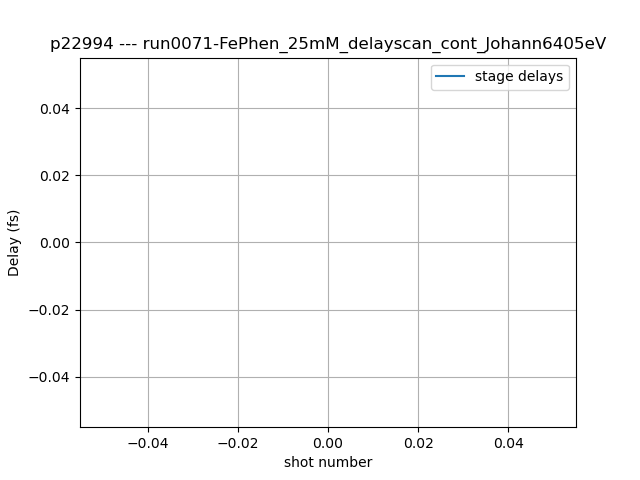

In [17]:
plt.figure()
plt.title(titlestring)
#plt.plot(Delays_fs_shot, '.',ms=0.5, label = 'TT corrected delays')
plt.plot(Delays_fs_shot, label = 'stage delays')
plt.xlabel('shot number')
plt.ylabel('Delay (fs)')
plt.legend (loc='best')
plt.grid()
plt.show()

In [18]:
np.shape(projections_on['JF10T01V01:ROI_Ka'])

NameError: name 'projections_on' is not defined

In [17]:
minvalue = -600 
maxvalue = 1100
binsize = 20

#######################################################################################

binList = np.arange(minvalue, maxvalue, binsize)
bin_centres = (binList[:-1] + binList[1:])/2
delay_rebin = np.arange(minvalue + binsize/2, maxvalue - binsize/2, binsize)

s_rebin_on = {}
s_rebin_off = {}
err_s_rebin_on  = {}
err_s_rebin_off = {}

for j,ROI in enumerate(ROIs):
    ROI_size = np.array(meta[ROI+'-roi'])[1][1]-np.array(meta[ROI+'-roi'])[1][0]
    print (ROI_size)
    
    temp_s_on  = np.array(projections_on[ROI])[:,:ROI_size]
    temp_s_off  = np.array(projections_off[ROI])[:,:ROI_size]
    
    spec_rebin_on   = np.zeros((len(bin_centres), ROI_size)) 
    spec_rebin_off  = np.zeros((len(bin_centres), ROI_size))
    err_spec_rebin_on   = np.zeros((len(bin_centres), ROI_size))
    err_spec_rebin_on   = np.zeros((len(bin_centres), ROI_size))
    howmany = []
    
    for i in range(len(bin_centres)):
        cond1 = Delays_fs_shot >= binList[i]
        cond2 = Delays_fs_shot < binList[i+1]

        idx = np.where(cond1*cond2)[0]
        howmany.append(len(idx))

        spec_rebin_on[i]  = np.mean(temp_s_on[idx,:], axis=0)
        spec_rebin_off[i] = np.mean(temp_s_off[idx,:], axis=0)
        err_spec_rebin_on[i] = np.std(temp_s_on[idx,:], axis=0)
        err_spec_rebin_off[i] = np.std(temp_s_off[idx,:], axis=0)
        
    s_rebin_on[ROI]   = spec_rebin_on
    s_rebin_off[ROI]  = spec_rebin_off

fig = plt.figure(figsize = (7,5))
ax1 = fig.add_subplot(111)
ax2 = plt.twinx(ax1)

delayrange = np.arange(0, len(delay_rebin), 1)
ax1.plot(delay_rebin, np.array(howmany), color = 'darkorange')
ax2.scatter(delay_rebin, delayrange, s = 5)

ax1.set_ylabel('shots per bin', color='darkorange')
ax1.grid()
plt.show()

#os.makedirs(savedir, exist_ok=True)
#plt.savefig(savedir + '/' + 'bins_population.png')

1100


NameError: name 'projections_on' is not defined

Saving the data - number of pulses per bin

In [35]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
df = pd.DataFrame({
    "delay": [delay_rebin], 
    "bin_pulses": [np.array(howmany)]
})

csv_file = os.path.join(savedir, 'vonHamos_run075_5000pulses.csv')
df.to_csv(csv_file, index=False)

print('Data saved in {}/run_data.csv'.format(savedir))

Data saved in /sf/alvra/data/p22994/work/Saved_data//run_data.csv


Energy calibration - pixel to energy

In [28]:
ka2 = 1981 - 1500
ka1 = 2143 - 1500

m = (6404 - 6391)/(ka1 - ka2)
q = (ka1*6391-ka2*6404)/(ka1-ka2)
m                 # pixel-to-eV

0.08024691358024691

In [29]:
yaxis_e = m*(yaxis-1500) + q

In [30]:
yaxis_e

array([6352.40123457, 6352.48148148, 6352.5617284 , ..., 6440.43209877,
       6440.51234568, 6440.59259259], shape=(1100,))

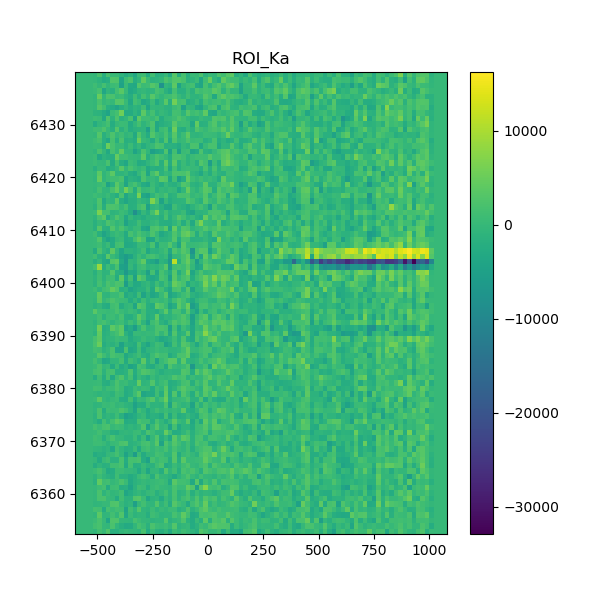

In [31]:
ROI = 'JF10T01V01:ROI_Ka'

bin_ = 13   # rebining energy bins to correspond to ~ 1 eV

vmin = None
vmax = None

##########################################################
ROI_size = np.array(meta[ROI+'-roi'])[1][1]-np.array(meta[ROI+'-roi'])[1][0]
plt.figure(figsize=(6,6))

matrix_on = s_rebin_on[ROI]
matrix_off =  s_rebin_off[ROI]


yaxis = np.arange(np.array(meta[ROI+'-roi']).flatten()[-2], np.array(meta[ROI+'-roi']).flatten()[-1], 1)
y_axis_rebin, matrix_on_rebin  = plot_tool_static_2D(matrix_on, 0, yaxis_e, bin_)
y_axis_rebin, matrix_off_rebin = plot_tool_static_2D(matrix_off, 0, yaxis_e, bin_)

pp = np.transpose( np.asarray(matrix_on_rebin) - np.asarray(matrix_off_rebin))

plt.title(ROI.split(':')[-1])
#plt.plot(Delay_fs, (np.transpose(np.asarray(matrix_on_rebin) - np.asarray(matrix_off_rebin))[31]))

#plt.pcolormesh(Delay_fs, y_axis_rebin, np.transpose(np.asarray(matrix_on_rebin) - np.asarray(matrix_off_rebin)), vmin = vmin, vmax = vmax)
plt.pcolormesh(delay_rebin, y_axis_rebin, pp, vmin = vmin, vmax = vmax)
#plt.pcolormesh(delay_rebin, y_axis_rebin, np.transpose(np.asarray(matrix_on_rebin)), vmin = vmin, vmax = vmax)
#plt.pcolormesh(Delay_fs, y_axis_rebin, np.transpose(np.asarray(matrix_off_rebin)), vmin = vmin, vmax = vmax)
plt.colorbar()
#plt.ylabel(ylabel)
#plt.axhline(y = 5098, color = 'r', linestyle = '-')
#plt.axvline(x = 2.55, color = 'r', linestyle = '-')

#plt.xlabel('{} ({})'.format(scan.parameters['name'][0], scan.parameters['units'][0]))
plt.show()

In [32]:
energy = 6403.85
index_energy = np.arange(len(y_axis_rebin))[(np.array(y_axis_rebin) > energy)][0]
cut_e = np.array(pp)[index_energy,:]
index_energy

np.int64(49)

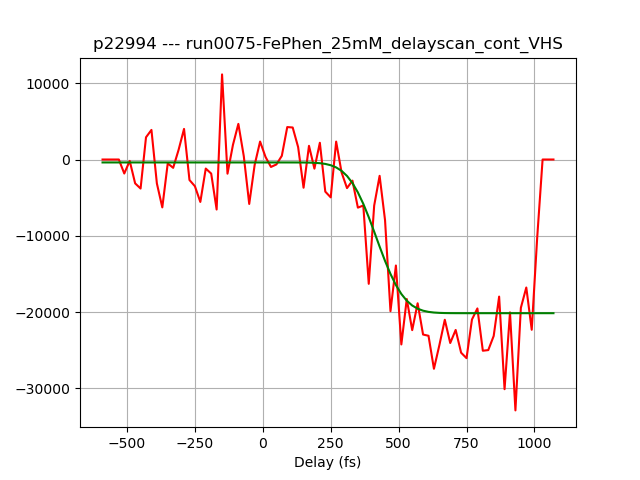

Width = 189.7857 fs


In [33]:
indexNans = ~(np.isnan(delay_rebin) | np.isnan(cut_e))
delay_rebin = delay_rebin[indexNans]
cut_e=  cut_e[indexNans]

fit = Fit(errfunc_fwhm, estimate_errfunc_parameters)
fit.estimate(delay_rebin, cut_e)
fit.p0 = better_p0(fit.p0, 0, 0) 

fit.fit(delay_rebin,cut_e, maxfev=200000)     
pp_fit = fit.eval(delay_rebin)
t0_fs = fit.popt[0]
width_fs = fit.popt[2]

plt.figure()
plt.title(titlestring)
#plt.errorbar(delay_rebin, PPs, err_PP, lw=1,color='red', markersize=0,capsize=1,capthick=1, ecolor='red',elinewidth=1)
plt.plot(delay_rebin, cut_e, color='red')
plt.plot(delay_rebin, pp_fit, color='green')
plt.xlabel('Delay (fs)')
plt.grid()
plt.show()
print("Width = {:.4f} fs".format(abs(width_fs)))

In [114]:
ka2 = 1981 - 1500
ka1 = 2143 - 1500

m = (6404 - 6391)/(ka1 - ka2)
q = (ka1*6391-ka2*6404)/(ka1-ka2)
m

0.08024691358024691

In [115]:
yaxis_e = m*(yaxis-1500) + q

In [116]:
yaxis_e

array([6352.40123457, 6352.48148148, 6352.5617284 , ..., 6440.43209877,
       6440.51234568, 6440.59259259])

In [165]:
1/m*400

4984.615384615385

In [144]:
400*20/650

12.307692307692308

In [19]:
minvalue = -500 
maxvalue = 1000
binsize = 20

#######################################################################################

binList = np.arange(minvalue, maxvalue, binsize)
bin_centres = (binList[:-1] + binList[1:])/2
delay_rebin = np.arange(minvalue + binsize/2, maxvalue - binsize/2, binsize)
ONs  = np.zeros(len(bin_centres))
OFFs = np.zeros(len(bin_centres))
PPs  = np.zeros(len(bin_centres))
err_PP = np.zeros(len(bin_centres))


for i in range(len(bin_centres)):
    cond1 = Delays_fs_shot >= binList[i]
    cond2 = Delays_fs_shot < binList[i+1]
    idx = np.where(cond1*cond2)[0]

    pump   = np.array(ints_on['JF10T01V01:ROI_Ka'])[idx]
    unpump = np.array(ints_off['JF10T01V01:ROI_Ka'])[idx]
    pumpprobe = pump - unpump
    
    ONs[i]  = np.nanmean(pump)
    OFFs[i] = np.nanmean(unpump)
    PPs[i]  = np.nanmean(pumpprobe)
    err_PP[i] = np.nanstd(pumpprobe)/np.sqrt(len(pumpprobe))

In [20]:
fit = Fit(errfunc_fwhm, estimate_errfunc_parameters)
fit.estimate(delay_rebin, PPs)
fit.p0 = better_p0(fit.p0, 0, 0) 

fit.fit(delay_rebin,PPs, maxfev=200000)     
pp_fit = fit.eval(delay_rebin)
t0_fs = fit.popt[0]
width_fs = fit.popt[2]

plt.figure()
plt.title(titlestring)
plt.errorbar(delay_rebin, PPs, err_PP, lw=1,color='red', markersize=0,capsize=1,capthick=1, ecolor='red',elinewidth=1)
plt.plot(delay_rebin, pp_fit, color='green')
plt.grid()
plt.show()
print("Width = {:.4f} fs".format(abs(width_fs)))

ValueError: array must not contain infs or NaNs

In [21]:
1/m

NameError: name 'm' is not defined

In [124]:
threshold_low = 2.5
threshold_high = 100000

channels_list = [channel_Izero110]

#####################################################

import sfdata.sfdatafile
sfdata.sfdatafile.ju = None
scan = SFScanInfo(jsonfile)

res, energy, intensity, intensity_peak, spectra, ROIs, meta = XES_static_ROIs(scan, channels_list, threshold_low, threshold_high, 0)
ints_rois        = unwrap_data(ROIs, len(scan), intensity)
ints_peak_rois   = unwrap_data(ROIs, len(scan), intensity_peak)
projections_rois = unwrap_data(ROIs, len(scan), spectra)
Izero = res['SAROP11-PBPS110:INTENSITY']

Processing: run0066-JetScan_Johann6405eV
Step 81 of 81: Processing acq0001

--------------------------------------------------------------------------------

JF10T01V01:ROI_Ka         201 / 201 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
JF10T01V01:ROI_Ka_thin    201 / 201 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAR-CVME-TIFALL4:EvtSet   201 / 201 -> 0% loss ▇▇▇▇▇▇▇▇▇▇
SAROP11-PBPS110:INTENSITY 199 / 201 -> 1% loss ▇▇▇▇▇▇▇▇▇

over the whole data set: 199 / 201 -> 1% loss
complete channels: 3 / 4 -> 25% incomplete

--------------------------------------------------------------------------------

FEL rep rate is 100.0 Hz


In [117]:
ROIs

['JF10T01V01:ROI_Ka', 'JF10T01V01:ROI_Ka_thin']

Plotting the VHS spectra

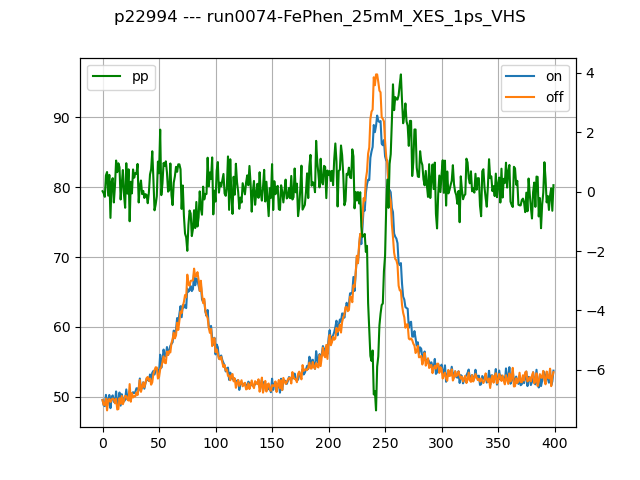

In [18]:
projections_on, projections_off = unwrap_data_PP(ROIs, len(scan), spectra_on, spectra_off)

intensity_Ka_on  = np.sum(projections_on['JF10T01V01:ROI_Ka'], axis=0)[400:800]
intensity_Ka_off = np.sum(projections_off['JF10T01V01:ROI_Ka'], axis=0)[400:800]

fig = plt.figure()
fig.suptitle(titlestring)
ax1 = fig.add_subplot(111)
ax2 = plt.twinx(ax1)

ax1.plot(intensity_Ka_on, label='on')
ax1.plot(intensity_Ka_off, label='off')
ax2.plot(np.array(intensity_Ka_on)-np.array(intensity_Ka_off), label='pp', color='green')

ax1.legend()
ax2.legend(loc='upper left')
ax1.grid()
plt.show()

Saving VHS data at fixed delay

In [10]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
df = pd.DataFrame({
    "ON": [intensity_Ka_on], 
    "OFF": [intensity_Ka_off],
    "Diff":[np.array(intensity_Ka_on)-np.array(intensity_Ka_off)],
})

csv_file = os.path.join(savedir, 'vonHamos_run073_VHS_transient.csv')
df.to_csv(csv_file, index=False)

print('Data saved in {}/run_data.csv'.format(savedir))

Data saved in /sf/alvra/data/p22994/work/Saved_data//run_data.csv


In [47]:
np.shape(intensity_on[1]['JF10T01V01:ROI_Ka'])

IndexError: list index out of range

In [27]:
intensity_Ka_on    = ints_on['JF10T01V01:ROI_Ka']
intensity_Ka_off    = ints_off['JF10T01V01:ROI_Ka']

fig = plt.figure()
fig.suptitle(titlestring)
ax1 = fig.add_subplot(111)
ax2 = plt.twinx(ax1)

ax1.plot(readbacks, intensity_Ka_on, label='on')
ax1.plot(readbacks, intensity_Ka_off, label='off')
ax2.plot(readbacks, np.array(intensity_Ka_on)-np.array(intensity_Ka_off), label='pp', color='green')


#intensity_Ka_n  = ints_rois['JF10T01V01:ROI_Ka_thin']

#intensity_peak_Ka  = ints_peak_rois['JF09T01V01:ROI_Ka']

# fit = Fit(gaussian, estimate_gaussian_parameters)
# fit.estimate(energy, intensity_peak_Ka)            # this sets some internal params 
# fit.fit(energy, intensity_peak_Ka)                  # calculate the fit
# intensity_fit = fit.eval(energy)            # evaluate the curve for plotting

#intensity2_Ka = ints2_rois['JF09T01V01:ROI_Ka']
#plt.figure()
#plt.title(titlestring)
#plt.plot(readbacks, intensity_Ka_on, label='on')
#plt.plot(readbacks, intensity_Ka_off, label='off')
#plt.plot(readbacks, np.array(intensity_Ka_on)-np.array(intensity_Ka_off), label='off')

#plt.plot(energy, intensity_Ka_n, label='narrow')

#plt.plot(energy, intensity_peak_Ka, label='peak +/- 3 pxl')
#plt.plot(energy, intensity_fit, label='{}'.format(fit.popt[2]*2.355))
#ax2.set_ylim(-100000, 100000)
ax1.legend()
ax2.legend(0)
ax1.grid()
plt.show()

NameError: name 'ints_on' is not defined

In [893]:
from scipy.signal import find_peaks

peaks,_ = find_peaks(prime_si333, height=1000)
print (peaks, len(prime_si333))

[20 59] 100


In [894]:
pxl_flex = np.arange(200)
energy_flex = - 13/56*pxl_flex + 6417.928571428572
pxl_si331 = np.arange(70)
energy_si331 = - 13/27*pxl_si331 + 6417.481481481482
pxl_si333 = np.arange(100)
energy_si333 = - 13/39*pxl_si333 + 6410.666666666667

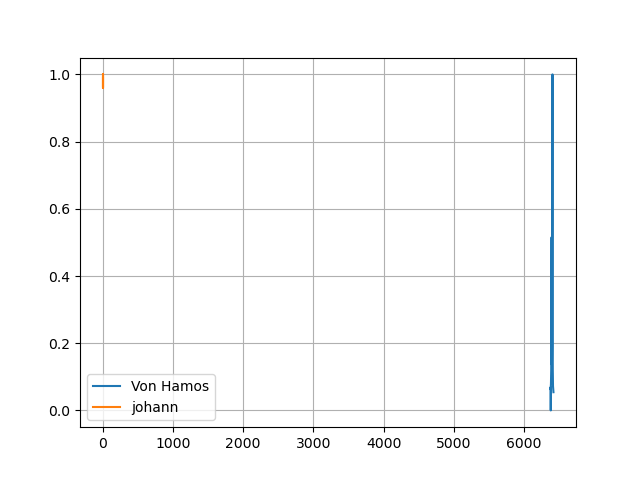

In [895]:
plt.figure()
#plt.title(titlestring)
#plt.pcolormesh(energy, np.arange(len(np.array(projection).T)), np.array(projection).T)
#plt.pcolormesh(np.array(projection).T)
plt.plot(energy_flex, flex_vhs/np.max(flex_vhs), label= 'Von Hamos')
plt.plot(energy, np.array(intensity_Ka)/np.max(intensity_Ka), label= 'johann')
#plt.plot(energy_si331, prime_si331/np.max(prime_si331), label= 'prime si331')
#plt.plot(energy_si333, prime_si333/np.max(prime_si333), label= 'prime si333')
plt.legend()
plt.grid()
plt.show()

## Loading from the raw data 

In [245]:
def load_JF_static(fname, pgroup, gain_file=None, pedestal_file=None, nshots=None, double_pixel='keep'):
    #fname = _correct_path(fname, pgroup)
    with ju.File(fname, gain_file=gain_file, pedestal_file=pedestal_file, double_pixels=double_pixel) as juf:
        images = juf[:nshots]
        pulse_ids = juf["pulse_id"][:nshots].T[0]
    return (images, pulse_ids)

In [246]:
from pathlib import Path
runnumber = 17
pgroup = 'p22994'

det = 'JF09T01V01'
thr_low  = 3
thr_high = 100000
roi1 = (300, 600, 100, 180)
#roi1 = (385, 387, 131, 133)

jsonfile = glob.glob('/sf/alvra/data/{}/raw/*{:04d}*/meta/scan.json'.format(pgroup, runnumber))[0]
scan = SFScanInfo(jsonfile)
energy = scan.readbacks

titlestring = str( pgroup + ' --- ' +jsonfile.split('/')[-3])
filelist = sorted(glob.glob('/sf/alvra/data/{}/raw/*{:04d}*/raw_data/*.{}.h5'.format(pgroup, runnumber, det)))
proj_all = []
int_all  = []
for file in filelist:
    clear_output(wait=True)
    print ('Processing {}'.format(file))
    imgs = load_JF_static(file, pgroup, double_pixel='mask')[0]
    imgs = threshold(imgs, thr_low, thr_high)
    print (np.shape(imgs))
    #imgs = convert_to_photon_num_range(imgs, (6,7))
    imgs = np.sum(imgs, axis=0)
    roi_Ka = crop_roi(imgs, roi1)
    proj_all.append(np.sum(roi_Ka, axis=0)) 
    int_all.append(np.sum(roi_Ka))
proj_all=np.array(proj_all)
#images = np.average(imgs_all, axis=0)

Processing /sf/alvra/data/p22994/raw/run0017-FLEX_vonHamos_Fe25um/raw_data/acq0005.JF09T01V01.h5
Auto-located gain file: /sf/jungfrau/config/gainMaps/JF09T01V01/gains.h5
Auto-located pedestal file: /sf/alvra/data/p22994/raw/JF_pedestals/20251029_153144.JF09T01V01.res.h5
jungfrau file: 08:19 29.10.2025
pedestal file: 15:32 29.10.2025
    mtime difference: -7:13:00.015811
(1001, 514, 1030)


In [259]:
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
runname

'run0017-FLEX_vonHamos_Fe25um'

In [260]:
ka2 = 166
ka1 = 110

m = (6404 - 6391)/(ka1 - ka2)
q = (ka1*6391-ka2*6404)/(ka1-ka2)
yaxis = np.arange(0, 300)
yaxis_e = m*(yaxis) + q

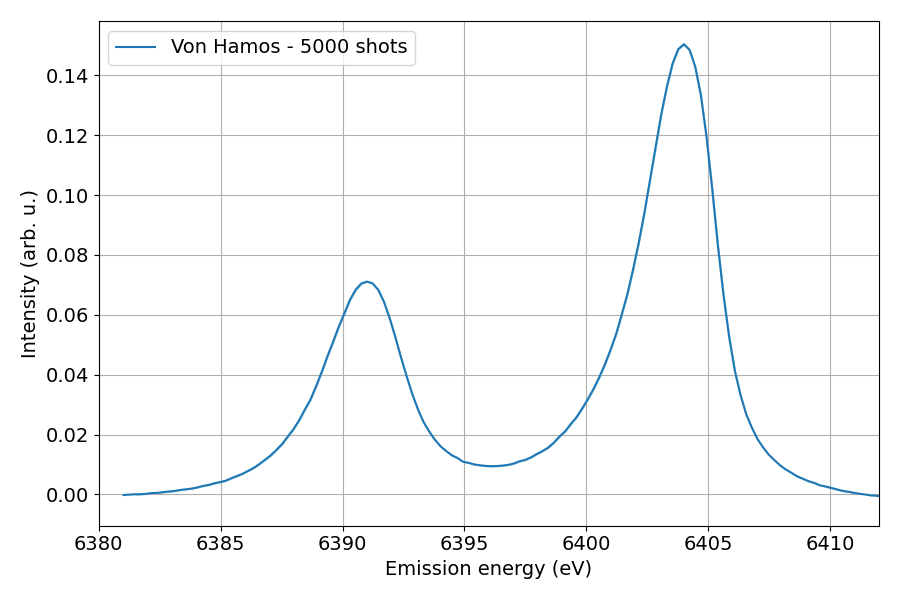

In [264]:
#plt.figure(figsize=(8,8/1.618))
plt.figure(figsize=(9,6))

plt.rcParams.update({'font.size': 14})
#plt.title('Von Hamos spectrometer - 5000 shots')

energy = yaxis_e[50:-90]
intensity = np.sum(proj_all, axis=0)[50:-90]
intensity = intensity - np.mean(intensity[-5:])
err_intensity = np.sqrt(intensity)

#plt.pcolormesh(roi_Ka)
delta = energy[0]-energy[1]
plt.plot(energy, intensity/(np.sum(intensity)*delta), label='Von Hamos - 5000 shots')
plt.fill_between(energy, (intensity-err_intensity)/(np.sum(intensity)*delta), (intensity+err_intensity)/(np.sum(intensity)*delta), color='lightblue')

# ## ********** Adding the Johann spectrum -- run64 ***************
# delta = rbk[1]-rbk[0]
# plt.plot(rbk, int_Ka/(np.sum(int_Ka)*delta), label='Johann - 100 shots/step')
# plt.fill_between(rbk, (int_Ka-err_int)/(np.sum(int_Ka)*delta), (int_Ka+err_int)/(np.sum(int_Ka)*delta), color='navajowhite')


#plt.plot(yaxis, np.sum(proj_all, axis=0))
plt.legend(loc='upper left')
plt.ylabel('Intensity (arb. u.)')
plt.xlabel('Emission energy (eV)')
#plt.colorbar()
plt.grid()
plt.tight_layout()
plt.xlim(6380, 6412)
plt.show()

plt.savefig(savedir + '/' + '{}.png'.format(runname))
#plt.savefig(savedir + '/' + 'comparison.png')

In [57]:
# Save to CSV
savedir='/sf/alvra/data/p22994/work/Saved_data/'
runname=jsonfile.split('/')[-3]
df = pd.DataFrame({
    "energy": [energy], 
    "intensity": [intensity],
    "err_intensity": [err_intensity]
})

csv_file = os.path.join(savedir, '{}.csv'.format(runname))
df.to_csv(csv_file, index=False)

In [46]:
np.sqrt(10**2 + 12**2 + 15**2)

np.float64(21.656407827707714)

In [26]:
roi1 = (300, 490, 80, 200)
roi_Ka_VHS = crop_roi(images, roi1)
proj_Ka = np.sum(roi_Ka_VHS, axis=0)
np.shape(proj_Ka)

(190,)

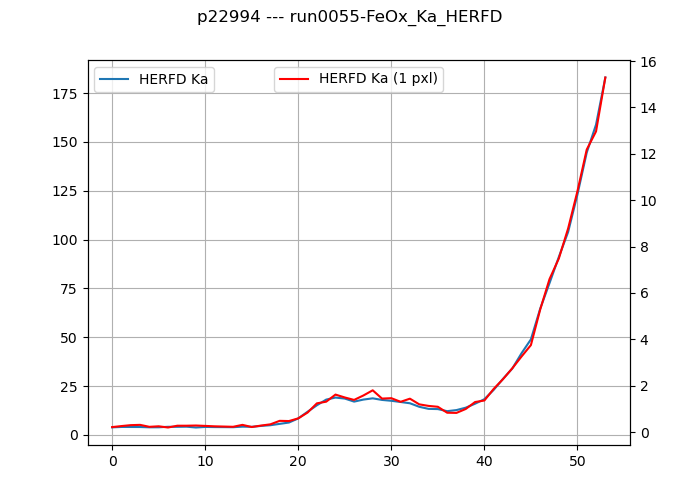

In [70]:
lineout = np.sum(proj_all.T[85:100, :], axis=0)
lineout1 = proj_all.T[93, :]


fig = plt.figure(figsize = (7,5))
fig.suptitle(titlestring)
ax1 = fig.add_subplot(111)
ax2 = plt.twinx(ax1)
#plt.plot(proj_Ka, label='threshold={}'.format(thr_low))
ax1.plot(lineout, label='HERFD Ka')
ax2.plot(lineout1, color='red', label='HERFD Ka (1 pxl)')
ax1.grid()
ax1.legend(loc='upper left')
ax2.legend(loc='upper center')
plt.show()